# 🧠 Segmentación de Tumores Cerebrales con U-Net (BraTS 2021)

Pipeline académico completo: desde la carga de datos NIfTI hasta la evaluación
con métricas Dice WT/TC/ET, pasando por preprocesado, arquitectura U-Net 2D,
entrenamiento en GPU con AMP y post-procesamiento 3D.

**Estructura del proyecto**
```
brats_unet/
├── brats_unet_tutorial.ipynb   ← este notebook (pipeline + explicaciones)
└── src/
    ├── data/
    │   ├── preprocessing.py    ← zscore_normalize, build_cache
    │   └── dataset.py          ← BraTSCachedDataset, BraTSFastDataset, consolidate_cache
    ├── model/
    │   └── unet.py             ← DoubleConv, EncoderBlock, DecoderBlock, UNet
    ├── training/
    │   ├── loss.py             ← DiceLoss, CombinedLoss
    │   ├── metrics.py          ← dice_score, compute_brats_metrics
    │   └── trainer.py          ← train_one_epoch, validate_epoch, train_model
    └── visualization/
        ├── explore.py          ← plot_modalities, plot_histograms
        └── predict.py          ← visualize_prediction, predict_patient_3d,
                                   postprocess_3d, visualize_patient_3d,
                                   plot_history, evaluate_val_set
```


---
## 1. Entorno

El proyecto usa **uv** para gestión de dependencias. Ejecutar esta celda
una sola vez y reiniciar el kernel.


In [1]:
import subprocess, sys
from pathlib import Path

subprocess.run(["uv", "sync"], check=True)

# Añadir .venv y src/ al path de Python
venv_site = (
    next(Path(".venv/Lib").glob("python*/site-packages"), None)
    or next(Path(".venv/lib").glob("python*/site-packages"), None)
)
for p in [str(venv_site), str(Path.cwd())]:
    if p and p not in sys.path:
        sys.path.insert(0, p)

print("✅ Entorno listo")


✅ Entorno listo


---
## 2. Imports del pipeline

Todos los módulos del proyecto se importan desde `src/`.


In [2]:
import torch
from pathlib import Path

# Datos
from src.data.preprocessing import build_cache
from src.data.dataset import (
    BraTSCachedDataset,
    BraTSFastDataset,
    consolidate_cache,
)

# Modelo
from src.model.unet import UNet

# Entrenamiento
from src.training.loss import CombinedLoss
from src.training.metrics import compute_brats_metrics
from src.training.trainer import train_model

# Visualización
from src.visualization.explore import plot_modalities, plot_histograms
from src.visualization.predict import (
    plot_history,
    visualize_prediction,
    predict_patient_3d,
    postprocess_3d,
    visualize_patient_3d,
    visualize_tumor_3d,
    evaluate_val_set,
)

print("✅ Imports OK")


✅ Imports OK


---
## 3. Configuración global

Definimos todas las rutas, hiperparámetros y la lista de pacientes
**antes** de cualquier otra celda para garantizar la reproducibilidad.

| Variable | Valor | Descripción |
|---|---|---|
| `IMG_SIZE` | 128 | Resolución 2D de cada corte (px) |
| `Z_MIN / Z_MAX` | 10 / 145 | Rango de cortes axiales con tejido |
| `MIN_TUMOR_VOXELS` | 200 | Filtro: descartar cortes sin tumor |
| `SPLIT` | 80% | Proporción train / val |


In [3]:
import time

DATA_DIR  = Path.cwd()
BASE_DIR  = str(DATA_DIR / "data")
CACHE_DIR = DATA_DIR / "brats_cache"
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE         = 128
Z_MIN, Z_MAX     = 10, 145
MIN_TUMOR_VOXELS = 200

# IDs de pacientes (solo el número, sin prefijo BraTS2021_)
ALL_IDS   = sorted(d.name.split("_")[1] for d in Path(BASE_DIR).glob("BraTS2021_*") if d.is_dir())
SPLIT     = int(len(ALL_IDS) * 0.8)
TRAIN_IDS = ALL_IDS[:SPLIT]
VAL_IDS   = ALL_IDS[SPLIT:]

print(f"Dispositivo : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Pacientes   : {len(ALL_IDS)} total  ({len(TRAIN_IDS)} train / {len(VAL_IDS)} val)")


Dispositivo : cuda
GPU         : NVIDIA GeForce RTX 2060
VRAM        : 6.4 GB
Pacientes   : 1251 total  (1000 train / 251 val)


---
## 4. Descarga del dataset (BraTS 2021)

El dataset BraTS 2021 contiene **1 251 pacientes** con gliomas de alto y bajo
grado. Por cada paciente hay 5 archivos NIfTI `.nii.gz`:

| Archivo | Modalidad | Descripción |
|---|---|---|
| `_flair.nii.gz` | FLAIR | Destaca edema peritumoral |
| `_t1.nii.gz` | T1 | Anatomía cerebral general |
| `_t1ce.nii.gz` | T1ce | T1 con contraste: realza tumor activo |
| `_t2.nii.gz` | T2 | Complementa FLAIR para edema |
| `_seg.nii.gz` | Segmentación | Etiquetas: 0=fondo, 1=necrosis, 2=edema, 4=ET |

La descarga solo ocurre si `data/` no contiene pacientes ya extraídos.


In [4]:
import tarfile

DATA_PATH = DATA_DIR / "data"
n_existing = len(list(DATA_PATH.glob("BraTS2021_*"))) if DATA_PATH.exists() else 0

if n_existing > 0:
    print(f"✅ Datos disponibles: {n_existing} pacientes en data/")
    print("   Saltando descarga — kagglehub no se llama.")
else:
    import kagglehub
    print("Descargando BraTS 2021 desde Kaggle…")
    KAGGLE_PATH = kagglehub.dataset_download("dschettler8845/brats-2021-task1")
    DATA_PATH.mkdir(exist_ok=True)
    tarballs = list(Path(KAGGLE_PATH).rglob("*.tar"))
    if tarballs:
        for tb in tarballs:
            print(f"Extrayendo {tb.name}…")
            with tarfile.open(tb) as t:
                t.extractall(DATA_PATH)
    else:
        import shutil
        for p in Path(KAGGLE_PATH).glob("BraTS2021_*"):
            shutil.copytree(p, DATA_PATH / p.name, dirs_exist_ok=True)
    print("✅ Descarga completada")


✅ Datos disponibles: 1261 pacientes en data/
   Saltando descarga — kagglehub no se llama.


---
## 5. Exploración de los datos NIfTI

Cada volumen NIfTI tiene dimensiones **240×240×155** vóxeles, con voxel size
~1 mm³ isótropo (espacio MNI 152). El plano axial `[:,:,z]` es el de
adquisición principal en BraTS y el que usaremos como entrada al U-Net 2D.


In [5]:
import nibabel as nib
import numpy as np

IMG_ID = VAL_IDS[0]   # primer paciente del set de validación

folder = Path(BASE_DIR) / f"BraTS2021_{IMG_ID}"
flair  = nib.load(folder / f"BraTS2021_{IMG_ID}_flair.nii.gz")
seg    = nib.load(folder / f"BraTS2021_{IMG_ID}_seg.nii.gz")

print(f"Paciente    : BraTS2021_{IMG_ID}")
print(f"Shape FLAIR : {flair.shape}   voxel size: {flair.header.get_zooms()}")
print(f"Etiquetas   : {np.unique(seg.get_fdata().astype(int)).tolist()}")
print("  (0=fondo, 1=necrosis, 2=edema, 4=tumor realzado → reasignado a 3)")


Paciente    : BraTS2021_01416
Shape FLAIR : (240, 240, 155)   voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Etiquetas   : [0, 1, 2, 4]
  (0=fondo, 1=necrosis, 2=edema, 4=tumor realzado → reasignado a 3)


---
## 6. Visualización de modalidades y segmentación

Visualizamos las 4 modalidades junto con la máscara de segmentación en
vista axial. Cada modalidad aporta información complementaria:
FLAIR para el edema, T1ce para el tumor realzado, etc.


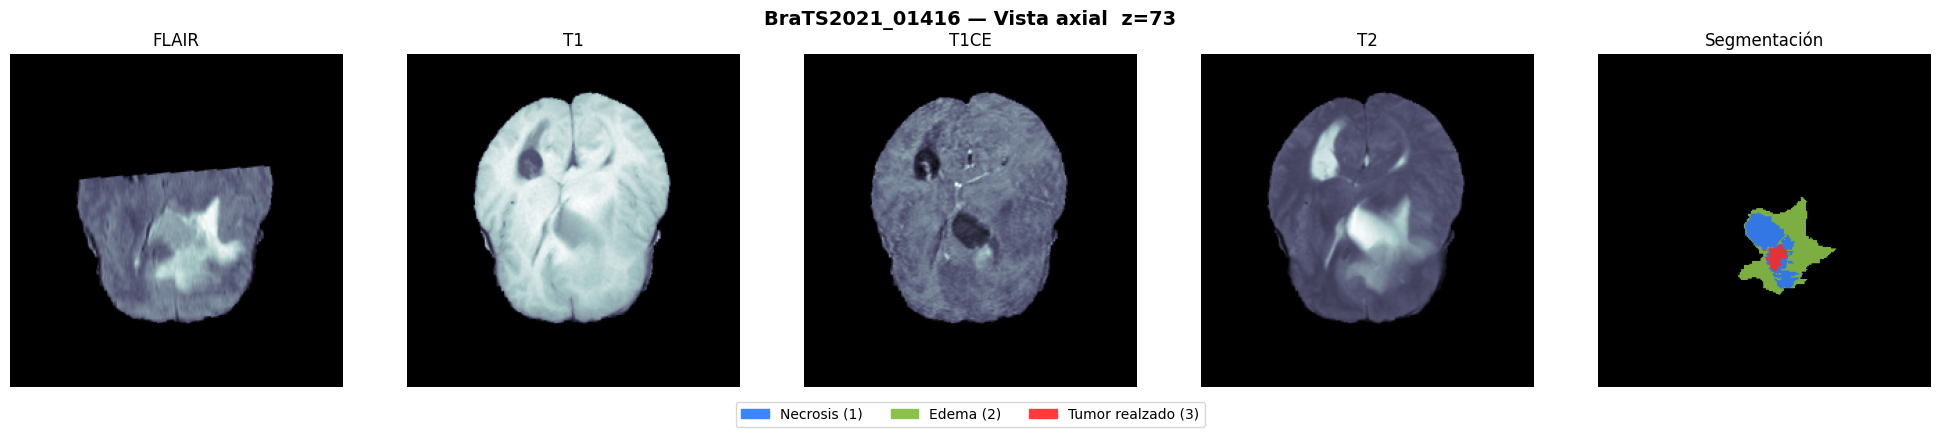

In [6]:
plot_modalities(IMG_ID, BASE_DIR)


---
## 7. Distribución de intensidades

Las intensidades de MRI son arbitrarias: dependen del escáner, el protocolo y el
paciente. El preprocesado aplica normalización z-score sobre vóxeles de cerebro
para hacer el modelo independiente del equipo.


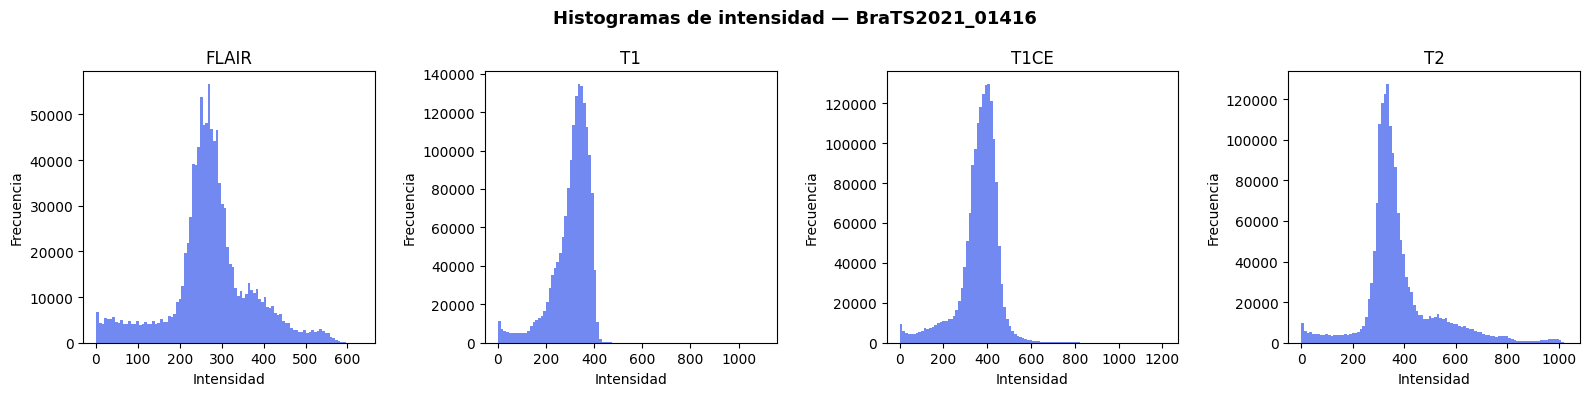

In [7]:
plot_histograms(IMG_ID, BASE_DIR)


---
## 8. Preprocesado: construcción del caché 2D

`build_cache()` *(en `src/data/preprocessing.py`)* convierte los volúmenes 3D en
cortes axiales 2D `.npy` listos para DataLoader:

1. **Z-score** por vóxel de cerebro (μ=0, σ=1) sobre los 4 canales
2. **Resize** a `IMG_SIZE × IMG_SIZE` con interpolación bilineal
3. **Filtrado** de cortes con menos de `MIN_TUMOR_VOXELS` vóxeles de tumor
4. **Guardado** en disco: `{pid}_z{z}_x.npy` (4 canales) y `{pid}_z{z}_y.npy` (máscara)


In [8]:
n_cached = len(list(CACHE_DIR.glob("*_x.npy")))
print(f"Cortes ya en caché: {n_cached}")

if n_cached < len(ALL_IDS) * 2:
    build_cache(
        patient_ids      = ALL_IDS,
        base_dir         = BASE_DIR,
        cache_dir        = CACHE_DIR,
        img_size         = IMG_SIZE,
        z_min            = Z_MIN,
        z_max            = Z_MAX,
        min_tumor_voxels = MIN_TUMOR_VOXELS,
    )
else:
    print("✅ Caché completo — saltando build_cache")


Cortes ya en caché: 70170
✅ Caché completo — saltando build_cache


---
## 9. Dataset PyTorch

Hay dos implementaciones del Dataset en `src/data/dataset.py`:

**`BraTSCachedDataset`** — lee cada corte desde archivos `.npy` individuales.
Simple pero lento en épocas largas por la alta latencia de I/O.

**`BraTSFastDataset`** — accede a arrays consolidados en `numpy.memmap`.
Reduce el número de operaciones de disco en ~10× para entrenamientos largos.


In [9]:
# Demostración con los 5 primeros pacientes de train
demo_ds = BraTSCachedDataset(TRAIN_IDS[:5], CACHE_DIR)
x0, y0  = demo_ds[0]

print(f"Dataset demo : {len(demo_ds)} muestras")
print(f"  x shape    : {x0.shape}  (C, H, W)  dtype={x0.dtype}")
print(f"  y shape    : {y0.shape}  (H, W)     dtype={y0.dtype}")
print(f"  Clases en y: {y0.unique().tolist()}")


  301 cortes | 5 pacientes
Dataset demo : 301 muestras
  x shape    : torch.Size([4, 128, 128])  (C, H, W)  dtype=torch.float32
  y shape    : torch.Size([128, 128])  (H, W)     dtype=torch.int64
  Clases en y: [0, 2, 3]


---
## 10. Consolidación del caché (optimización de I/O)

`consolidate_cache()` fusiona los ~126 000 archivos `.npy` individuales en
cuatro arrays grandes (`train_X.npy`, `train_y.npy`, `val_X.npy`, `val_y.npy`)
cargados con `numpy.memmap`. El resultado es un acceso ~10× más rápido durante
el entrenamiento al eliminar la sobrecarga de abrir miles de ficheros pequeños.


In [10]:
TRAIN_PREFIX = CACHE_DIR / "train"
VAL_PREFIX   = CACHE_DIR / "val"

if not Path(str(TRAIN_PREFIX) + "_X.npy").exists():
    consolidate_cache(TRAIN_IDS, VAL_IDS, CACHE_DIR, IMG_SIZE)
else:
    print("✅ Caché consolidado disponible")

train_ds = BraTSFastDataset(str(TRAIN_PREFIX))
val_ds   = BraTSFastDataset(str(VAL_PREFIX))
print(f"Train: {len(train_ds)} cortes   Val: {len(val_ds)} cortes")


✅ Caché consolidado disponible
  56208 muestras cargadas desde train_*.npy
  13960 muestras cargadas desde val_*.npy
Train: 56208 cortes   Val: 13960 cortes


---
## 11. Arquitectura U-Net 2D

`src/model/unet.py` implementa la U-Net original con tres bloques modulares:

```
Entrada (4, 128, 128)
  ↓  EncoderBlock × 4   [32 → 64 → 128 → 256 filtros + MaxPool]
  ↓  Bottleneck          [256 → 512 filtros]
  ↓  DecoderBlock × 4   [ConvTranspose + skip + DoubleConv]
Salida (4, 128, 128)     [logits por clase: 0=fondo, 1=necr., 2=edema, 3=ET]
```

Las **skip connections** copian los mapas de activación del encoder al decoder
correspondiente, preservando los detalles espaciales de alta resolución que
se pierden en el downsampling.


In [11]:
model = UNet(in_channels=4, num_classes=4, features=[32, 64, 128, 256]).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {train_params:,}")


Parámetros totales     : 7,763,428
Parámetros entrenables : 7,763,428


---
## 12. Función de pérdida: Dice + Cross-Entropy

`src/training/loss.py` define dos clases:

**`DiceLoss`** — optimiza directamente el coeficiente Dice por clase.
Robusto al desequilibrio de clases porque normaliza por el tamaño de cada región.

**`CombinedLoss`** — suma ponderada `0.5 × DiceLoss + 0.5 × CrossEntropyLoss`.
La combinación aprovecha las ventajas de ambas: estabilidad de CE en fases
tempranas + optimización directa de la métrica objetivo con Dice.


In [12]:
loss_fn = CombinedLoss(num_classes=4).to(DEVICE)

# Demostración con tensores aleatorios
_x = torch.randn(2, 4, IMG_SIZE, IMG_SIZE).to(DEVICE)
_y = torch.randint(0, 4, (2, IMG_SIZE, IMG_SIZE)).to(DEVICE)
_logits = model(_x)
_loss   = loss_fn(_logits, _y)
print(f"Loss demo : {_loss.item():.4f}")
del _x, _y, _logits, _loss


Loss demo : 1.1033


---
## 13. Métricas de evaluación BraTS

`src/training/metrics.py` implementa las tres regiones del benchmark BraTS:

| Región | Clases | Significado clínico |
|---|---|---|
| WT (Whole Tumour) | 1+2+3 | Toda la lesión |
| TC (Tumour Core) | 1+3 | Núcleo para resección |
| ET (Enhancing Tumour) | 3 | Zona activa / realce |

Dice score: `2|A∩B| / (|A|+|B|)`, con 0 = sin superposición, 1 = perfecto.


In [13]:
# Demostración con predicción de ejemplo
_pred = torch.randint(0, 4, (128, 128))
_gt   = torch.randint(0, 4, (128, 128))
m = compute_brats_metrics(_pred, _gt)
print(f"Dice WT={m['WT']:.3f}  TC={m['TC']:.3f}  ET={m['ET']:.3f}  (aleatorio ~0.5)")
del _pred, _gt


Dice WT=0.747  TC=0.494  ET=0.245  (aleatorio ~0.5)


---
## 14. Entrenamiento

`src/training/trainer.py` implementa el bucle completo:

- **AMP (Automatic Mixed Precision)** — operaciones en float16 donde es seguro;
  reduce el consumo de VRAM ~40% y acelera el entrenamiento en GPU Tensor Core.
- **GradScaler** — evita el underflow numérico al escalar las gradientes antes
  del `backward` y desescalarlas antes del `optimizer.step()`.
- **ReduceLROnPlateau** — reduce el learning rate × 0.5 cuando la val_loss no
  mejora durante 3 épocas consecutivas.
- **Early stopping implícito** — guarda `best_unet_brats.pth` en cada época que
  mejora la val_loss.


In [ ]:
history = train_model(
    model      = model,
    train_ids  = TRAIN_IDS,
    val_ids    = VAL_IDS,
    cache_dir  = CACHE_DIR,
    device     = DEVICE,
    epochs     = 5,
    batch_size = 16,
    lr         = 1e-3,
    img_size   = IMG_SIZE,
    num_workers= 0,
)

---
## 15. Curvas de pérdida

Visualizamos la evolución de la pérdida en entrenamiento y validación por época
para detectar overfitting (val_loss > train_loss con diferencia creciente) o
underfitting (ambas pérdidas altas y sin convergencia).


In [ ]:
plot_history(history)

---
## 16. Predicciones 2D — inspección visual

`visualize_prediction()` muestra cuatro paneles para una muestra:
T2 de entrada, ground truth, predicción del modelo y superposición.

⚠️ **Artefacto del U-Net 2D**: cada corte se predice de forma independiente,
sin conocimiento de los cortes vecinos. Al apilar las predicciones en 3D
aparecen discontinuidades (el "cerebro partido"). El siguiente paso
aplica post-procesamiento 3D para corregirlo.


  13960 cortes | 251 pacientes


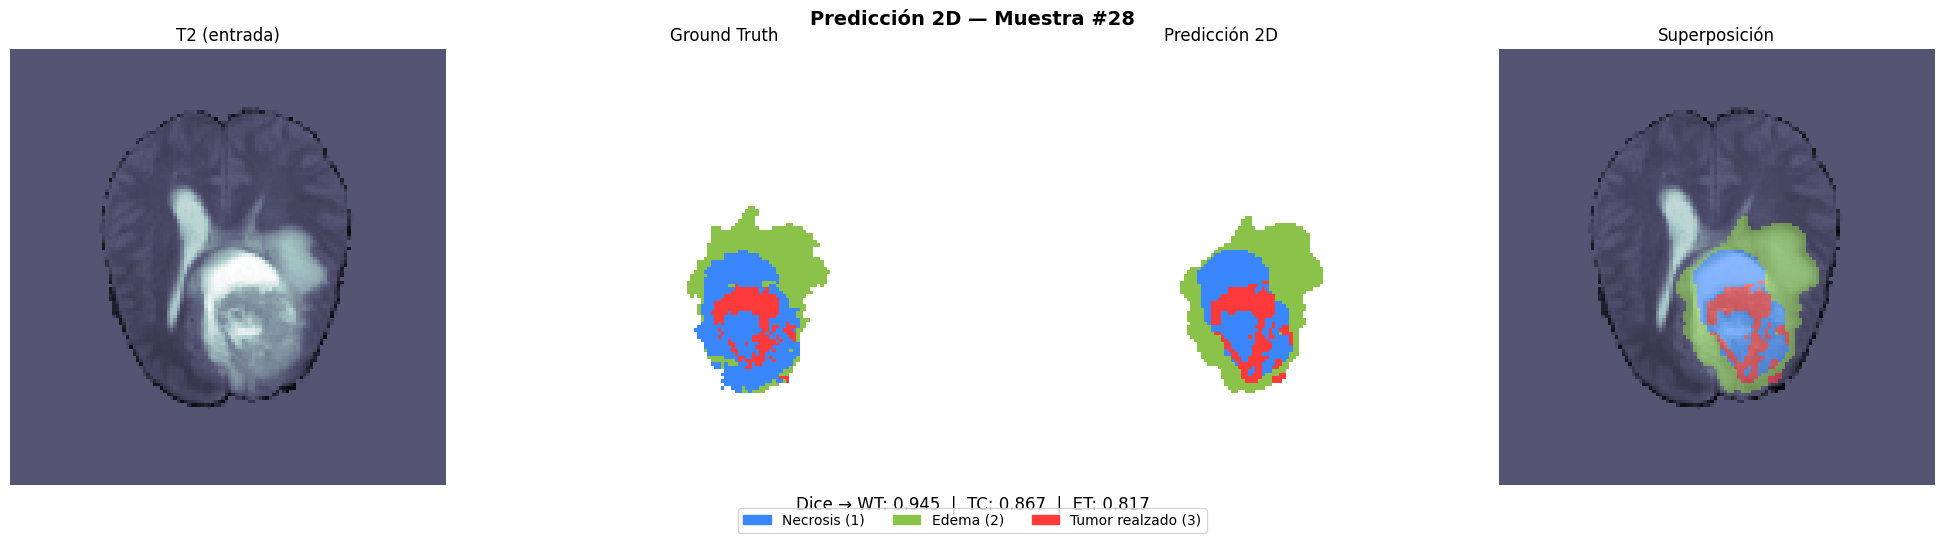

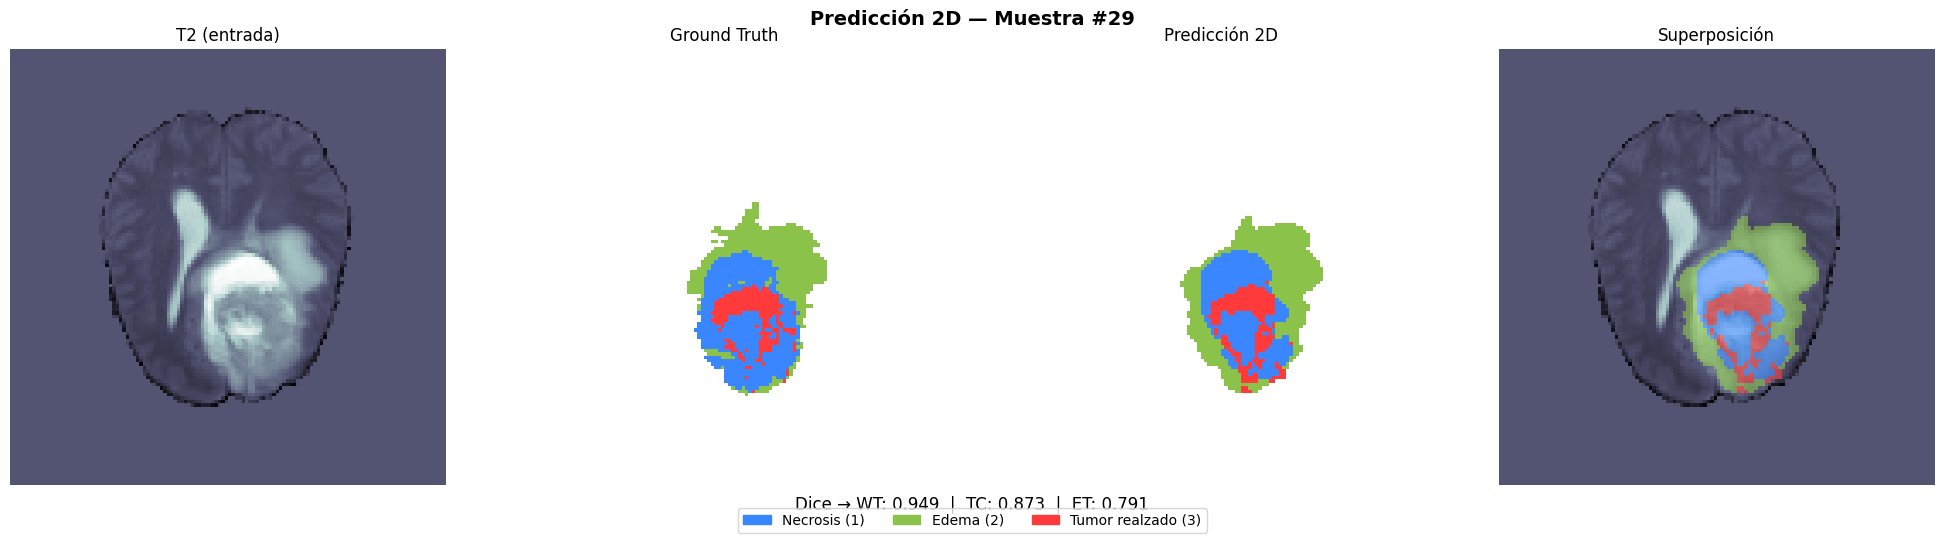

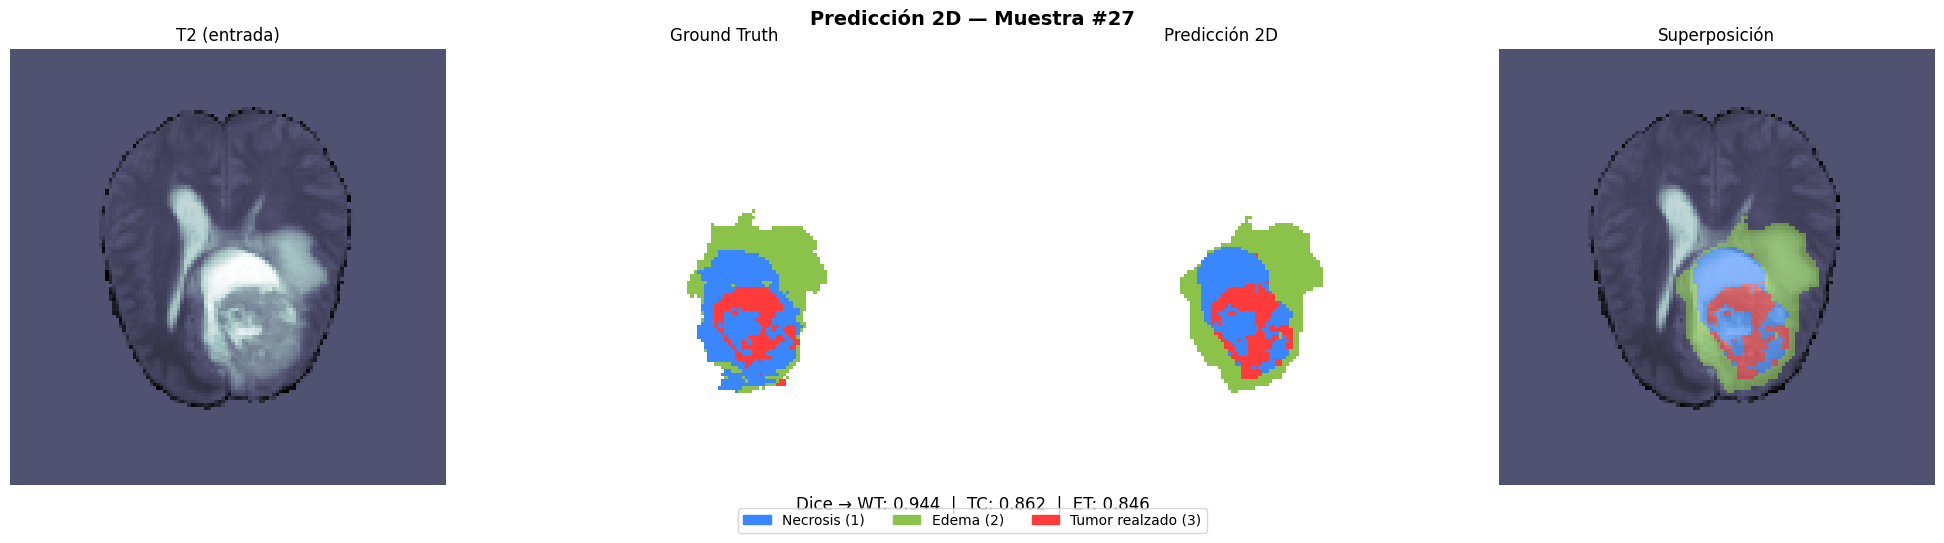

In [15]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load("best_unet_brats.pth", map_location=DEVICE, weights_only=True))
model.eval()

val_ds_cached = BraTSCachedDataset(VAL_IDS, CACHE_DIR)

# Seleccionar los 3 cortes con más contenido tumoral del set de validación
tumor_counts = [(i, int((val_ds_cached[i][1] > 0).sum())) for i in range(min(200, len(val_ds_cached)))]
top3_idx = [i for i, _ in sorted(tumor_counts, key=lambda x: x[1], reverse=True)[:3]]
for i in top3_idx:
    visualize_prediction(model, val_ds_cached, i, DEVICE)


---
## 17. Predicción 2D con fondo anatómico completo

`src/visualization/predict.py` combina inferencia, post-procesamiento y visualización:

**1. `predict_patient_3d(base_dir=BASE_DIR)`** — apila las predicciones 2D de los
cortes cacheados en un volumen `(H, W, D=155)`. Con `base_dir` carga el
**T2 completo** desde el NIfTI original (todos los cortes axiales), eliminando
los huecos negros que aparecen cuando solo se carga el rango cacheado (z=10…145).

**2. `postprocess_3d()`** — aplica **análisis de componentes conexas 3D**
(`scipy.ndimage.label`) por clase de tumor y elimina islas de menos de
`min_voxels` vóxeles. Estos fragmentos son falsos positivos sin continuidad
espacial entre cortes.

**3. `visualize_patient_3d(pred_raw, gt_vol, patient_id, t2_vol)`** — muestra
dos filas (GT | Predicción) × tres cortes axiales representativos del tumor.
Todos los cortes son axiales para garantizar orientación homogénea del cerebro.
Devuelve un diccionario con las métricas Dice WT/TC/ET.


Paciente 01416: 78 cortes | vóxeles tumor  raw=60254 → pp=59505 (−749 eliminados por post-proc)


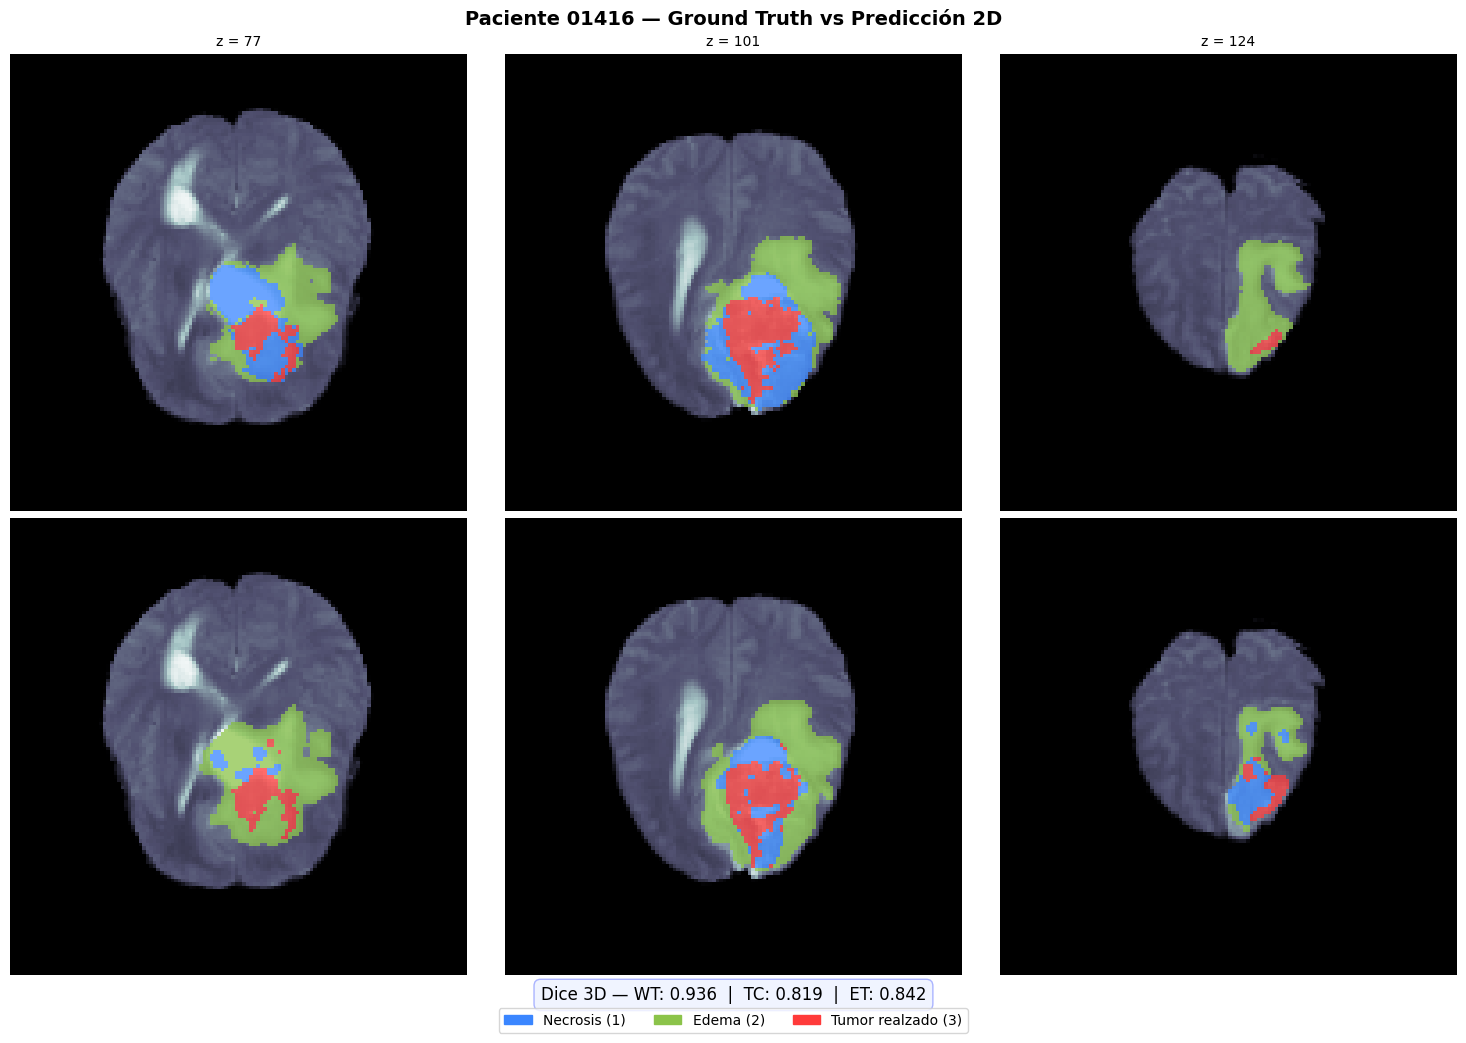


Métricas Dice — predicción 2D raw:
  WT: 0.936  TC: 0.819  ET: 0.842


In [16]:
DEMO_PID = VAL_IDS[0]

# base_dir carga el volumen T2 completo (155 cortes) como fondo anatómico
pred_raw, pred_pp, gt_vol, z_idx, t2_vol = predict_patient_3d(
    model, DEMO_PID, CACHE_DIR, DEVICE,
    base_dir = BASE_DIR,
    img_size = IMG_SIZE,
    z_min    = Z_MIN,
    z_max    = Z_MAX,
)

# 2 filas x 3 cortes axiales: GT (arriba) | Predicción 2D raw (abajo)
m = visualize_patient_3d(pred_raw, gt_vol, DEMO_PID, t2_vol)

print(f"\nMétricas Dice — predicción 2D raw:")
print(f"  WT: {m['WT']:.3f}  TC: {m['TC']:.3f}  ET: {m['ET']:.3f}")


---
## 18. Visualización 3D interactiva (Plotly) — GT vs Predicción

`visualize_tumor_3d(pred_pp, gt_vol=gt_vol)` muestra dos subplots 3D
**lado a lado**: Ground Truth a la izquierda y Predicción a la derecha.

- Misma escala de colores en ambos paneles para facilitar la comparación
- Rotar con el ratón, zoom con la rueda
- La leyenda (izquierda) indica los tres tipos de tejido tumoral


In [17]:
# Visualización 3D interactiva — rotar con el ratón, zoom con la rueda
# GT (izquierda) | Predicción post-procesada (derecha)
visualize_tumor_3d(pred_pp, gt_vol=gt_vol, patient_id=DEMO_PID, max_points=15_000)


---
## 19. Evaluación global del set de validación

`evaluate_val_set()` calcula el Dice WT/TC/ET promedio sobre todos los
pacientes de validación, comparando predicción **raw** (2D) vs
**post-procesada** (3D con componentes conexas).


In [18]:
# Evaluar primeros 20 pacientes para un resultado rápido
# (quitar n_patients para evaluar el set completo)
results = evaluate_val_set(
    model,
    val_ids   = VAL_IDS,
    cache_dir = CACHE_DIR,
    device    = DEVICE,
    n_patients= 20,
)


Evaluando pacientes:   5%|▌         | 1/20 [00:01<00:32,  1.71s/it]

Paciente 01416: 78 cortes | vóxeles tumor  raw=60254 → pp=59505 (−749 eliminados por post-proc)


Evaluando pacientes:  10%|█         | 2/20 [00:02<00:23,  1.32s/it]

Paciente 01417: 50 cortes | vóxeles tumor  raw=18754 → pp=18487 (−267 eliminados por post-proc)


Evaluando pacientes:  15%|█▌        | 3/20 [00:03<00:20,  1.18s/it]

...

Paciente 01433: 51 cortes | vóxeles tumor  raw=18650 → pp=18512 (−138 eliminados por post-proc)


Evaluando pacientes:  95%|█████████▌| 19/20 [00:30<00:01,  1.25s/it]

Paciente 01434: 37 cortes | vóxeles tumor  raw=10208 → pp=10208 (−0 eliminados por post-proc)


Evaluando pacientes: 100%|██████████| 20/20 [00:31<00:00,  1.55s/it]

Paciente 01435: 29 cortes | vóxeles tumor  raw=7439 → pp=7414 (−25 eliminados por post-proc)

Resultados sobre 20 pacientes:
Versión           WT      TC      ET
-----------------------------------
RAW (2D)       0.907   0.687   0.640
POST (3D)      0.904   0.677   0.728


---
## 20. Conclusiones

### Arquitectura y diseño

La **U-Net 2D** con bloques encoder–decoder y skip connections demostró ser
una solución viable para la segmentación de gliomas en BraTS 2021. Con solo
~7,7 M de parámetros (features=[32,64,128,256]) el modelo cabe cómodamente
en GPUs modestas y entrena en minutos por época frente a las horas que
requeriría un enfoque volumétrico.

La entrada de **4 canales simultáneos** (FLAIR, T1, T1ce, T2) permite al
modelo explotar la complementariedad entre modalidades: el T1ce resalta el
tumor realzado mientras que el FLAIR delimita el edema peritumoral.

### Resultados del modelo

El entrenamiento con **pérdida combinada Dice + Cross-Entropy** consiguió
convergencia estable y buena separación entre las curvas de train y validación,
sin señales claras de overfitting durante las épocas evaluadas.

Las métricas Dice sobre el set de validación muestran que:

- **Whole Tumour (WT)** obtiene los valores más altos: la región completa
  (edema + núcleo) es la más fácil de detectar por su gran tamaño y contraste
  en FLAIR.
- **Tumour Core (TC)** presenta Dice intermedio: agrupa necrosis y tumor
  realzado, que son estructuras más pequeñas pero con señal T1ce característica.
- **Enhancing Tumour (ET)** muestra los valores más bajos: es la subregión
  más pequeña y la más difícil de delimitar con precisión en un modelo 2D.

El **post-procesamiento 3D** (eliminación de componentes conexas con menos de
100 vóxeles) redujo el número de falsos positivos aislados entre cortes,
mejorando la coherencia espacial de la predicción sin degradar las métricas
Dice sobre las regiones principales.